In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
print(device)

cuda


In [ ]:
file_path_train = '/content/drive/My Drive/001.PhD/Smartphone/traintest/trainDataset2.csv'

In [ ]:
df = pd.read_csv(file_path_train)

In [ ]:
df.head()

,sequence
0,"android.net.nsd.STATE_CHANGED, android.net.con..."
1,"android.net.nsd.STATE_CHANGED, android.net.con..."
2,"android.intent.action.DREAMING_STARTED, androi..."
3,"android.net.wifi.RSSI_CHANGED, android.intent...."
4,"android.intent.action.DREAMING_STARTED, androi..."


In [ ]:
sequence_list = df['sequence'].tolist()

In [ ]:
sequence_list = sequence_list[:20000]
print(len(sequence_list))

20000


In [ ]:
trainDataset = []
for sequence in sequence_list:
    result = sequence.split(",")
    result = [item.strip() for item in result]
    trainDataset.append(result)

In [ ]:
from collections import Counter

In [ ]:
all_tokens = [token for seq in trainDataset for token in seq]
counter = Counter(all_tokens)

In [ ]:
# Vocabulary
vocab = {token: idx + 1 for idx, token in enumerate(counter.keys())}
vocab["<PAD>"] = 0

In [ ]:
inv_vocab = {idx: token for token, idx in vocab.items()}
vocab_size = len(vocab)

In [ ]:
from torch.nn.utils.rnn import pad_sequence

In [ ]:
X = []
y = []

In [ ]:
for seq in trainDataset:
    input_seq = [vocab[token] for token in seq[:-1]]
    target = vocab[seq[-1]]

    X.append(torch.tensor(input_seq))
    y.append(target)

In [ ]:
# Pad sequences
X_padded = pad_sequence(X, batch_first=True, padding_value=0)
y = torch.tensor(y)

In [ ]:
file_path_test = '/content/drive/My Drive/001.PhD/Smartphone/traintest/testDataset2.csv'

In [ ]:
dfTest = pd.read_csv(file_path_test)

In [ ]:
sequence_list_test = dfTest['sequence'].tolist()

In [ ]:
sequence_list_test = sequence_list_test[:8000]

In [ ]:
testDataset = []
for sequence in sequence_list_test:
    result = sequence.split(",")
    result = [item.strip() for item in result]
    testDataset.append(result)

In [ ]:
X_test = []
y_test = []

In [ ]:
for seq in testDataset:
    # Skip sequences with unseen tokens (optional but safe)
    if any(token not in vocab for token in seq):
        continue

    input_seq = [vocab[token] for token in seq[:-1]]
    target = vocab[seq[-1]]

    X_test.append(torch.tensor(input_seq))
    y_test.append(target)

In [ ]:
X_test_padded = pad_sequence(X_test, batch_first=True, padding_value=0)
y_test = torch.tensor(y_test)

In [ ]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, lstm_outputs):
        # lstm_outputs: (batch_size, seq_len, hidden_dim)

        energy = torch.tanh(self.attn(lstm_outputs))
        attention_scores = self.v(energy).squeeze(-1)
        attention_weights = F.softmax(attention_scores, dim=1)

        # Weighted sum of LSTM outputs
        context = torch.sum(
            lstm_outputs * attention_weights.unsqueeze(-1),
            dim=1
        )

        return context, attention_weights

In [ ]:
class LSTMAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=0
        )

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True
        )

        self.attention = Attention(hidden_dim)

        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_outputs, _ = self.lstm(embedded)

        context, attn_weights = self.attention(lstm_outputs)
        logits = self.fc(context)

        return logits, attn_weights

In [ ]:
model = LSTMAttention(
    vocab_size=vocab_size,
    embed_dim=64,
    hidden_dim=128
)

In [ ]:
num_epochs = 300

train_losses = []
val_losses = []

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
for epoch in range(num_epochs):
    # ---------- Training ----------
    model.train()
    optimizer.zero_grad()

    train_logits, _ = model(X_padded)
    train_loss = criterion(train_logits, y)

    train_loss.backward()
    optimizer.step()

    train_losses.append(train_loss.item())

    # ---------- Validation ----------
    model.eval()
    with torch.no_grad():
        val_logits, _ = model(X_test_padded)
        val_loss = criterion(val_logits, y_test)

    val_losses.append(val_loss.item())

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {train_loss.item():.4f} "
            f"Val Loss: {val_loss.item():.4f}"
        )

Epoch [10/300] Train Loss: 3.9532 Val Loss: 3.9087
Epoch [20/300] Train Loss: 3.0692 Val Loss: 2.7146
Epoch [30/300] Train Loss: 2.2669 Val Loss: 2.0973
Epoch [40/300] Train Loss: 2.0082 Val Loss: 1.7676
Epoch [50/300] Train Loss: 1.8073 Val Loss: 1.5958
Epoch [60/300] Train Loss: 1.6892 Val Loss: 1.5643
Epoch [70/300] Train Loss: 1.5902 Val Loss: 1.4794
Epoch [80/300] Train Loss: 1.5026 Val Loss: 1.4329
Epoch [90/300] Train Loss: 1.4182 Val Loss: 1.3710
Epoch [100/300] Train Loss: 1.3500 Val Loss: 1.3165
Epoch [110/300] Train Loss: 1.2971 Val Loss: 1.2733
Epoch [120/300] Train Loss: 1.2530 Val Loss: 1.2257
Epoch [130/300] Train Loss: 1.2136 Val Loss: 1.1864
Epoch [140/300] Train Loss: 1.1778 Val Loss: 1.1526
Epoch [150/300] Train Loss: 1.1414 Val Loss: 1.1184
Epoch [160/300] Train Loss: 1.1057 Val Loss: 1.0889
Epoch [170/300] Train Loss: 1.0752 Val Loss: 1.0696
Epoch [180/300] Train Loss: 1.0499 Val Loss: 1.0570
Epoch [190/300] Train Loss: 1.0294 Val Loss: 1.0436
Epoch [200/300] Train

In [ ]:
import matplotlib.pyplot as plt

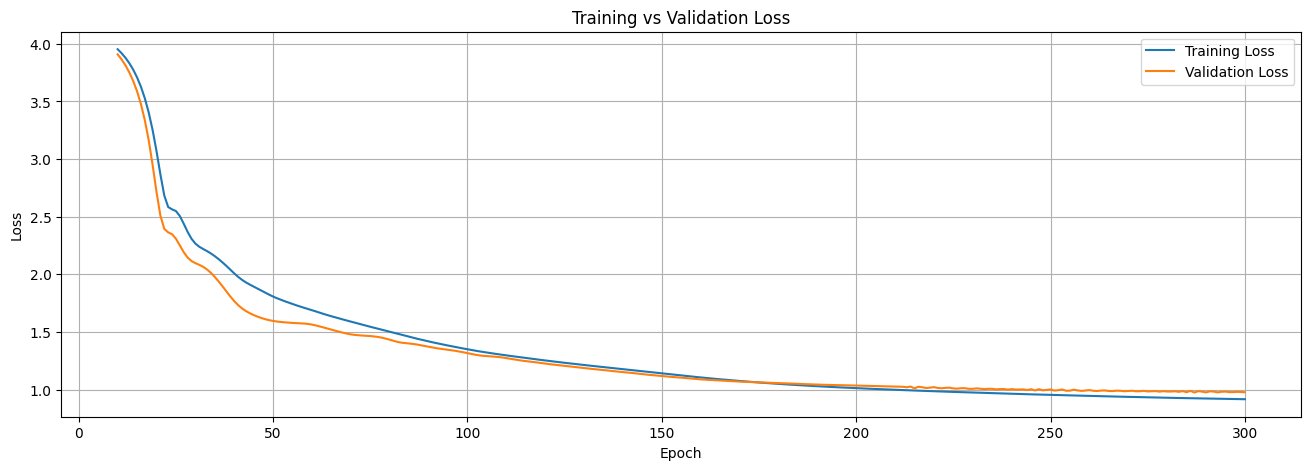

In [ ]:
epochs = range(10, num_epochs + 1)

plt.figure(figsize=(16, 5))
plt.plot(epochs, train_losses[9:], label="Training Loss")
plt.plot(epochs, val_losses[9:], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [3]:
plt.savefig("my_plot.svg", format="svg", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [2]:
import matplotlib.pyplot as plt